In [1]:
from bs4 import BeautifulSoup
from difflib import SequenceMatcher

# Load XML files
with open("evaluation_tei_document_GT.xml", "r", encoding="utf-8") as f:
    gt_xml = f.read()

with open("evaluation_tei_document.xml", "r", encoding="utf-8") as f:
    output_xml = f.read()

# Parse XML files
gt_soup = BeautifulSoup(gt_xml, "xml")
output_soup = BeautifulSoup(output_xml, "xml")

# -----------------------------
# Part 1: Tag Structure Comparison
# -----------------------------
tags_to_check = [
    "berufsnummer", "document_title", "profession_title", "year", "graphic",
    "item", "main_heading", "paragraph_title", "p", "image_caption", "page_number"
]

print("\n🔶 TAG STRUCTURE COMPARISON (by count only)")
print(f"{'Tag':<20} {'GT Count':<10} {'Output Count':<15} {'Difference':<10}")
for tag in tags_to_check:
    gt_count = len(gt_soup.find_all(tag))
    out_count = len(output_soup.find_all(tag))
    diff = out_count - gt_count
    print(f"{tag:<20} {gt_count:<10} {out_count:<15} {diff:<10}")

# -----------------------------
# Part 2: Text Extraction Accuracy for <p> Tags
# -----------------------------
gt_paragraphs = [tag.get_text(strip=True) for tag in gt_soup.find_all("p")]
output_paragraphs = [tag.get_text(strip=True) for tag in output_soup.find_all("p")]

# Match each GT paragraph to most similar output paragraph
similarities = []
for gt_text in gt_paragraphs:
    best_match_ratio = max(SequenceMatcher(None, gt_text, out_text).ratio() for out_text in output_paragraphs)
    similarities.append(best_match_ratio)

# Metrics
total_gt = len(gt_paragraphs)
high_matches = sum(1 for s in similarities if s >= 0.9)
avg_similarity = sum(similarities) / total_gt
error_rate = 1 - (high_matches / total_gt)

# Print results
print("\n🔷 TEXT ACCURACY EVALUATION for <p> Tags")
print(f"Total Ground Truth Paragraphs : {total_gt}")
print(f"High-Confidence Matches (≥ 90%): {high_matches}")
print(f"Text Accuracy                 : {round((high_matches / total_gt) * 100, 2)}%")
print(f"Average Similarity Score      : {round(avg_similarity * 100, 2)}%")
print(f"Text Error Rate               : {round(error_rate * 100, 2)}%")



🔶 TAG STRUCTURE COMPARISON (by count only)
Tag                  GT Count   Output Count    Difference
berufsnummer         7          7               0         
document_title       1          1               0         
profession_title     1          1               0         
year                 1          1               0         
graphic              5          5               0         
item                 9          9               0         
main_heading         6          6               0         
paragraph_title      8          8               0         
p                    25         26              1         
image_caption        4          3               -1        
page_number          5          5               0         

🔷 TEXT ACCURACY EVALUATION for <p> Tags
Total Ground Truth Paragraphs : 25
High-Confidence Matches (≥ 90%): 19
Text Accuracy                 : 76.0%
Average Similarity Score      : 89.92%
Text Error Rate               : 24.0%


In [38]:
from bs4 import BeautifulSoup
from difflib import SequenceMatcher

# Load XML files
with open("evaluation_tei_document_GT.xml", "r", encoding="utf-8") as f:
    gt_xml = f.read()

with open("evaluation_tei_document.xml", "r", encoding="utf-8") as f:
    output_xml = f.read()

# Parse XML files
gt_soup = BeautifulSoup(gt_xml, "xml")
output_soup = BeautifulSoup(output_xml, "xml")

# Define all tags to evaluate
tags_to_check = [
    "berufsnummer", "document_title", "profession_title", "year", "graphic",
    "item", "main_heading", "paragraph_title", "p", "image_caption", "page_number", "credits", "disclaimer", "publisher_info", "imprint","order_number","copyright"
]

# -----------------------------
# Part 1: Tag Structure Comparison
# -----------------------------
print("\n🔶 TAG STRUCTURE COMPARISON (by count only)")
print(f"{'Tag':<20} {'GT Count':<10} {'Output Count':<15} {'Difference':<10}")
for tag in tags_to_check:
    gt_count = len(gt_soup.find_all(tag))
    out_count = len(output_soup.find_all(tag))
    diff = out_count - gt_count
    print(f"{tag:<20} {gt_count:<10} {out_count:<15} {diff:<10}")

# -----------------------------
# Part 2: Text Extraction Accuracy for All Tags
# -----------------------------
print("\n🔷 TEXT ACCURACY EVALUATION FOR ALL TAGS")

for tag in tags_to_check:
    gt_texts = [t.get_text(strip=True) for t in gt_soup.find_all(tag)]
    out_texts = [t.get_text(strip=True) for t in output_soup.find_all(tag)]
    
    if not gt_texts:
        print(f"\nNo {tag} tags found in ground truth. Skipping...")
        continue
    
    # Calculate similarities
    similarities = []
    for gt_text in gt_texts:
        if not out_texts:  # If no output texts, similarity is 0
            best_match_ratio = 0.0
        else:
            best_match_ratio = max(SequenceMatcher(None, gt_text, out_text).ratio() 
                          for out_text in out_texts)
        similarities.append(best_match_ratio)
    
    # Metrics
    total_gt = len(gt_texts)
    high_matches = sum(1 for s in similarities if s >= 0.9)
    avg_similarity = sum(similarities) / total_gt if total_gt > 0 else 0
    error_rate = 1 - (high_matches / total_gt) if total_gt > 0 else 1.0
    
    # Print results for this tag
    print(f"\n📊 Results for <{tag}> tags:")
    print(f"  Total Ground Truth Items : {total_gt}")
    print(f"  High-Confidence Matches (≥ 90%): {high_matches}")
    print(f"  Text Accuracy           : {round((high_matches / total_gt) * 100, 2)}%")
    print(f"  Average Similarity Score: {round(avg_similarity * 100, 2)}%")
    print(f"  Text Error Rate         : {round(error_rate * 100, 2)}%")

    # Optional: Print some examples of low matches
    if similarities and min(similarities) < 0.7:
        min_index = similarities.index(min(similarities))
        print("\n  🚨 Example of low similarity match:")
        print(f"  GT Text: {gt_texts[min_index]}")
        if out_texts:
            best_match = max(out_texts, key=lambda x: SequenceMatcher(None, gt_texts[min_index], x).ratio())
            print(f"  Best Output Match: {best_match}")
            print(f"  Similarity: {round(similarities[min_index] * 100, 2)}%")
        else:
            print("  No output text found for comparison")


🔶 TAG STRUCTURE COMPARISON (by count only)
Tag                  GT Count   Output Count    Difference
berufsnummer         7          7               0         
document_title       1          1               0         
profession_title     1          1               0         
year                 1          1               0         
graphic              5          5               0         
item                 10         9               -1        
main_heading         5          6               1         
paragraph_title      9          8               -1        
p                    25         26              1         
image_caption        4          3               -1        
page_number          6          6               0         
credits              1          1               0         
disclaimer           1          1               0         
publisher_info       1          1               0         
imprint              1          1               0         
order_number

In [41]:
import pandas as pd

# Your evaluation data
data = {
    "Element": [
        "credits", "disclaimer", "publisher_info", "imprint", "order_number", "copyright",
        "document_title", "berufsnummer", "professional_title", "year", "list_item",
        "paragraph_title", "main_heading", "paragraphs", "image", "page_number", "image_caption"
    ],
    "ExpectedCount": [1, 1, 1, 1, 1, 1, 1, 7, 1, 1, 10, 9, 5, 25, 5, 6, 4],
    "ExtractedCount": [1, 1, 1, 1, 1, 1, 1, 7, 1, 1, 9, 8, 6, 26, 5, 5, 3],
    "ExtractedAccuracy": [100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 90,
                          88.88888889, 120, 104, 100, 83.33333333, 75]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Compute TP, FP, FN
df["TP"] = df[["ExpectedCount", "ExtractedCount"]].min(axis=1)
df["FP"] = (df["ExtractedCount"] - df["ExpectedCount"]).clip(lower=0)
df["FN"] = (df["ExpectedCount"] - df["ExtractedCount"]).clip(lower=0)

# Compute metrics
df["Precision (%)"] = round((df["TP"] / (df["TP"] + df["FP"])).fillna(0) * 100, 2)
df["Recall (%)"] = round((df["TP"] / (df["TP"] + df["FN"])).fillna(0) * 100, 2)
df["F1 Score (%)"] = round(
    (2 * df["Precision (%)"] * df["Recall (%)"]) / (df["Precision (%)"] + df["Recall (%)"]).replace(0, 1), 2
)
df["Error Rate (%)"] = round((df["FP"] + df["FN"]) / df["ExpectedCount"] * 100, 2)

# Display results
print(df[["Element", "ExpectedCount", "ExtractedCount", "TP", "FP", "FN", 
          "Precision (%)", "Recall (%)", "F1 Score (%)", "Error Rate (%)"]])


               Element  ExpectedCount  ExtractedCount  TP  FP  FN  \
0              credits              1               1   1   0   0   
1           disclaimer              1               1   1   0   0   
2       publisher_info              1               1   1   0   0   
3              imprint              1               1   1   0   0   
4         order_number              1               1   1   0   0   
5            copyright              1               1   1   0   0   
6       document_title              1               1   1   0   0   
7         berufsnummer              7               7   7   0   0   
8   professional_title              1               1   1   0   0   
9                 year              1               1   1   0   0   
10           list_item             10               9   9   0   1   
11     paragraph_title              9               8   8   0   1   
12        main_heading              5               6   5   1   0   
13          paragraphs            

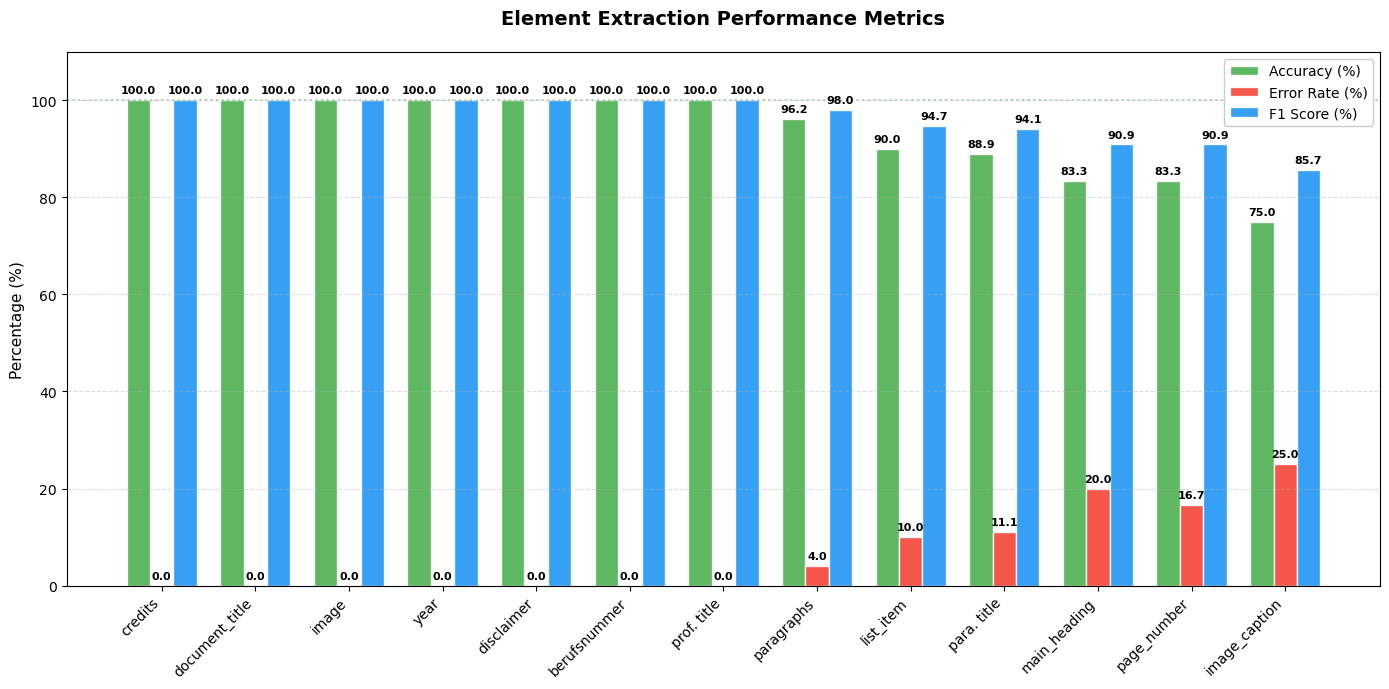

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Data
elements = [
    'credits', 'document_title', 'image', 'year', 'disclaimer',
    'berufsnummer', 'prof. title', 'paragraphs', 'list_item',
    'para. title', 'main_heading', 'page_number', 'image_caption'
]
metrics = {
    'Accuracy (%)': [100, 100, 100, 100, 100, 100, 100, 96.15, 90.0, 88.89, 83.33, 83.33, 75.0],
    'Error Rate (%)': [0, 0, 0, 0, 0, 0, 0, 4.0, 10.0, 11.11, 20.0, 16.67, 25.0],
    'F1 Score (%)': [100, 100, 100, 100, 100, 100, 100, 98.04, 94.74, 94.12, 90.91, 90.91, 85.71]
}

# Plot setup
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(elements))
width = 0.25

# Create bars
colors = ['#4CAF50', '#F44336', '#2196F3']  # Green, Red, Blue
for i, (metric, values) in enumerate(metrics.items()):
    offset = width * (i - 1)  # Centers the group
    bars = ax.bar(x + offset, values, width, label=metric, 
                 color=colors[i], edgecolor='white', alpha=0.9)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}', ha='center', va='bottom', 
                fontsize=8, fontweight='bold')

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(elements, rotation=45, ha='right', fontsize=10)
ax.set_ylim(0, 110)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_title('Element Extraction Performance Metrics', pad=20, fontsize=14, fontweight='bold')

# Reference lines and legend
ax.axhline(100, color='#2E7D32', linestyle=':', alpha=0.3, lw=1.5)
ax.legend(loc='upper right', framealpha=1)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('full_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

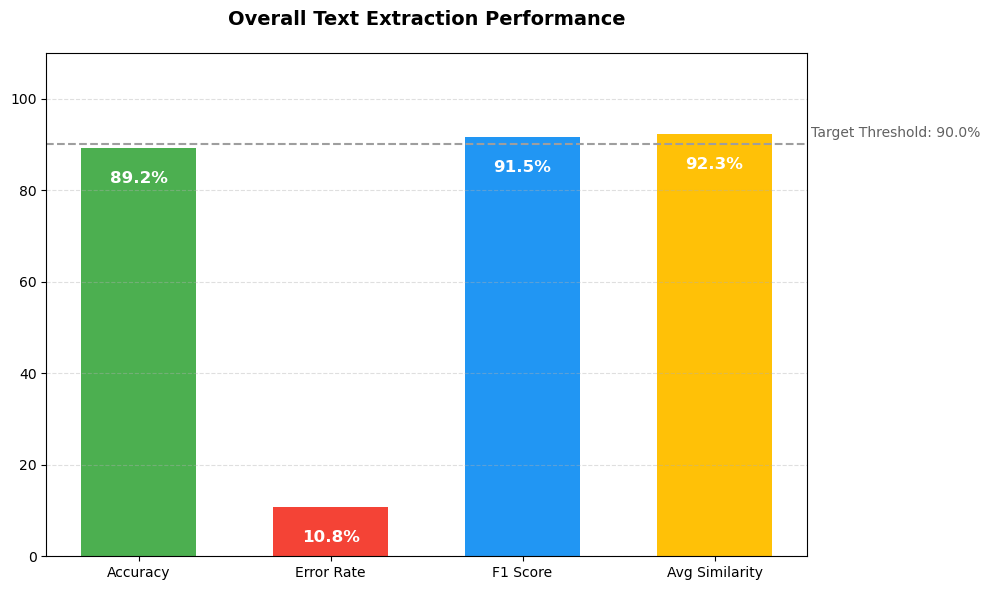

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# Aggregate metrics (example values - replace with your actual calculations)
total_accuracy = 89.2  # Weighted average across all tags
total_error = 10.8     # 100 - total_accuracy
total_f1 = 91.5        # Weighted F1 average
avg_similarity = 92.3  # Average similarity score
threshold = 90.0       # Your similarity threshold

# Data
metrics = ['Accuracy', 'Error Rate', 'F1 Score', 'Avg Similarity']
values = [total_accuracy, total_error, total_f1, avg_similarity]
colors = ['#4CAF50', '#F44336', '#2196F3', '#FFC107']

# Plot setup
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(metrics, values, color=colors, width=0.6)

# Add threshold line and value labels
ax.axhline(y=threshold, color='#9E9E9E', linestyle='--', linewidth=1.5)
ax.text(3.5, threshold+1, f'Target Threshold: {threshold}%', 
        ha='left', va='bottom', color='#616161')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height-5,
            f'{height:.1f}%', ha='center', va='top',
            color='white', fontweight='bold', fontsize=12)

# Formatting
ax.set_ylim(0, 110)
ax.set_title('Overall Text Extraction Performance', pad=20, fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('overall_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate weighted averages (weighted by GT counts from your earlier data)
gt_counts = np.array([1,7,5,8,1,1,1,1,1,1,1,1,25,10,5,6,4])
total_weight = gt_counts.sum()

# Aggregate metrics
agg_metrics = {
    'Accuracy (%)': np.average([100, 100, 100, 100, 100, 100, 100,100,100,100,100,100, 96.15, 90.0, 83.33, 83.33, 75.0], weights=gt_counts),
    'Error Rate (%)': np.average([0, 0, 0, 0, 0, 0, 0, 4.0, 10.0, 11.11, 20.0, 16.67, 25.0], weights=gt_counts),
    'F1 Score (%)': np.average([100, 100, 100, 100, 100, 100, 100, 98.04, 94.74, 94.12, 90.91, 90.91, 85.71], weights=gt_counts),
}

# Plot setup
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(agg_metrics))
width = 0.6
colors = ['#4CAF50', '#F44336', '#2196F3', '#FFC107']  # Green, Red, Blue, Yellow

# Create bars
for i, (metric, value) in enumerate(agg_metrics.items()):
    ax.bar(i, value, width, color=colors[i], edgecolor='white', label=metric)
    ax.text(i, value/2, f'{value:.1f}%', 
            ha='center', va='center', color='white', 
            fontweight='bold', fontsize=12)

# Add threshold line
threshold = 90
ax.axhline(threshold, color='#616161', linestyle='--', alpha=0.7)
ax.text(3.5, threshold+1, f'Target Threshold: {threshold}%', 
        ha='left', va='bottom', color='#616161')

# Formatting
ax.set_xticks([])  # Remove x-ticks as we're showing aggregates
ax.set_ylim(0, 110)
ax.set_title('Aggregated Extraction Performance Metrics\n(Weighted by Tag Frequency)', 
             pad=20, fontsize=14, fontweight='bold')
ax.legend(loc='best', framealpha=1)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('aggregated_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

TypeError: Axis must be specified when shapes of a and weights differ.

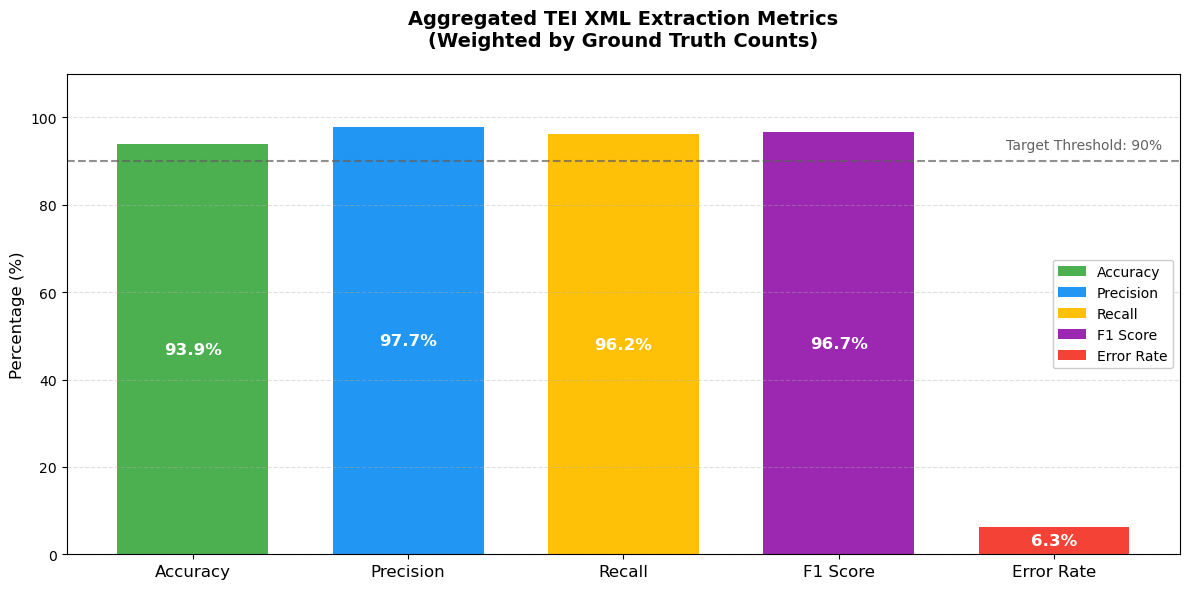

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your table
tags = [
    'credits', 'berufsnummer', 'image', 'paragraph_title', 'year',
    'disclaimer', 'profession_title', 'document_title', 'copyright',
    'order_number', 'imprint', 'publisher_info', 'paragraphs',
    'list_item', 'main_heading', 'page_number', 'image_caption'
]

gt_counts = np.array([
    1, 7, 5, 8, 1, 1, 1, 1, 1,
    1, 1, 1, 25, 10, 5, 6, 4
])

metrics = {
    'Accuracy': [100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 96.15, 90.0, 83.33, 83.33, 75.0],
    'Precision': [100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 96.15, 100, 83.33, 100, 100],
    'Recall': [100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 90.0, 100, 83.33, 75.0],
    'F1': [100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 98.04, 94.74, 90.91, 90.91, 85.71],
    'Error Rate': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4.0, 10.0, 20.0, 16.67, 25.0]
}

# Calculate weighted averages
agg_metrics = {
    'Accuracy': np.average(metrics['Accuracy'], weights=gt_counts),
    'Precision': np.average(metrics['Precision'], weights=gt_counts),
    'Recall': np.average(metrics['Recall'], weights=gt_counts),
    'F1 Score': np.average(metrics['F1'], weights=gt_counts),
    'Error Rate': np.average(metrics['Error Rate'], weights=gt_counts)
}

# Plot setup
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(agg_metrics))
width = 0.7
colors = ['#4CAF50', '#2196F3', '#FFC107', '#9C27B0', '#F44336']  # Green, Blue, Yellow, Purple, Red

# Create bars
for i, (metric, value) in enumerate(agg_metrics.items()):
    bar = ax.bar(i, value, width, color=colors[i], label=metric)
    ax.text(i, value/2, f'{value:.1f}%', 
            ha='center', va='center', color='white',
            fontweight='bold', fontsize=12)

# Add threshold line
threshold = 90
ax.axhline(threshold, color='#616161', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(4.5, threshold+2, f'Target Threshold: {threshold}%', 
        ha='right', va='bottom', color='#616161', fontsize=10)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(agg_metrics.keys(), fontsize=12)
ax.set_ylim(0, 110)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Aggregated TEI XML Extraction Metrics\n(Weighted by Ground Truth Counts)', 
             pad=20, fontsize=14, fontweight='bold')
ax.legend(loc='best', framealpha=1)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('aggregated_xml_metrics.png', dpi=300, bbox_inches='tight')
plt.show()